# A3I project backup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from entsoe import EntsoePandasClient
import pytz
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import xgboost as xgb
import shap
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

# Set the seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)
random_state = 42

# Macros
START_DATE = '2023-01-01'
END_DATE = '2023-12-31'
LATITUDE = 44.49 # Bologna's Latitude
LONGITUDE = 11.34 # Bologna's Longitude

ENTSOE_TOKEN = "14456526-8054-4a1b-9600-49167bdf441b" 
country_code = 'IT_NORD'

# Extending the temporal range to 7 years to obtain better insights on seasonality and trends
START_DATE_EXT = '2019-01-01'
END_DATE_EXT = '2025-12-31'
LATITUDE = 44.49 
LONGITUDE = 11.34 

c:\Users\Carmine2\Desktop\Università-Magistrale\Year_2\AI4I\Energy-Arbitrage-DFL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Ingestion and Market Context

Forecasting Day-Ahead electricity prices requires capturing both the supply-side constraints and demand-side behaviors of the power grid. To build a robust predictive pipeline, we integrated two primary data sources:

*Meteorological Data (Open-Meteo API)*: Variables such as solar radiation and wind speed are critical exogenous drivers. Due to the Merit Order Effect, the injection of renewable energy (which has a near-zero marginal cost) structurally depresses wholesale electricity prices.

*Market Clearing Prices (ENTSO-E API)*: The historical Day-Ahead prices serve as our target variable.

By aligning these datasets strictly on Coordinated Universal Time (UTC), we eliminated temporal inconsistencies caused by Daylight Saving Time (DST) transitions, ensuring a mathematically sound foundation for our sequential models.

In [2]:
# FETCHING METEOROLOGICAL FEATURES (Open-Meteo API)
def fetch_weather_features(lat, lon, start_date, end_date):
    """
    Extracts historical hourly weather features (Temperature, Solar Radiation, Wind)
    No API key required.
    """
    # Constructing the API URL with query parameters
    url = (f"https://archive-api.open-meteo.com/v1/archive?"
           f"latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}"
           f"&hourly=temperature_2m,direct_radiation,windspeed_10m&timezone=UTC")
    
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        df_weather = pd.DataFrame(data['hourly'])
        
        # Temporal casting and endpoint timezone handling
        df_weather['time'] = pd.to_datetime(df_weather['time'])
        df_weather.set_index('time', inplace=True)
        df_weather.index = df_weather.index.tz_localize('UTC') 
        
        # Column renaming for clarity
        df_weather.columns = ['Temperature_C', 'Solar_Radiation_W', 'Wind_Speed_ms']
        print(f"Weather data ingestion successful: {len(df_weather)} hourly records retrieved.")
        return df_weather
    else:
        print(f"Open-Meteo API Error: {response.status_code}")
        return None

# FETCHING DAY-AHEAD ENERGY PRICES (ENTSO-E API)
def fetch_energy_prices(api_token, country_code, start_date, end_date):
    """
    Extracts Day-Ahead market clearing prices (€/MWh).
    """
        
    print(f"Downloading Day-Ahead prices for zone {country_code}...")
    client = EntsoePandasClient(api_key=api_token)
    
    # Converting strings to timezone-aware Pandas Timestamps (Europe/Rome)
    tz = pytz.timezone('Europe/Rome')
    start = pd.Timestamp(start_date, tz=tz)
    end = pd.Timestamp(end_date, tz=tz)
    
    try:
        # Fetching Day-Ahead prices
        ts_prices = client.query_day_ahead_prices(country_code, start=start, end=end)
        df_prices = pd.DataFrame(ts_prices, columns=['Day_Ahead_Price_EUR_MWh'])
        
        df_prices.index.name = 'time'
        
        # Convert the index to UTC timezone to align with weather data
        df_prices.index = df_prices.index.tz_convert('UTC')
        
        print(f"Energy price ingestion successful: {len(df_prices)} hourly records retrieved.")
        return df_prices
    except Exception as e:
        print(f"ENTSO-E API Error: {e}")
        return None

In [3]:
# Downloading meteorological features
df_weather = fetch_weather_features(LATITUDE, LONGITUDE, START_DATE, END_DATE)

# Downloading Day-Ahead energy prices
df_prices = fetch_energy_prices(ENTSOE_TOKEN, 'IT_NORD', START_DATE, END_DATE)

# RELATIONAL JOIN (Temporal Alignment)
if df_weather is not None and df_prices is not None:
    
    # Aligning on the 'time' index (already in UTC) to ensure perfect temporal join
    df_master = df_weather.join(df_prices, how='inner')
    print(df_master.head())
elif df_weather is not None:
    print("\n WEATHER DATASET PREVIEW (Awaiting ENTSO-E Token for Prices)")
    print(df_weather.head())

Weather data ingestion successful: 8760 hourly records retrieved.
Energy price ingestion successful: 8736 hourly records retrieved.
                           Temperature_C  Solar_Radiation_W  Wind_Speed_ms  \
time                                                                         
2023-01-01 00:00:00+00:00            7.2                0.0            4.4   
2023-01-01 01:00:00+00:00            7.0                0.0            5.1   
2023-01-01 02:00:00+00:00            7.1                0.0            5.4   
2023-01-01 03:00:00+00:00            7.5                0.0            4.9   
2023-01-01 04:00:00+00:00            7.3                0.0            2.7   

                           Day_Ahead_Price_EUR_MWh  
time                                                
2023-01-01 00:00:00+00:00                   191.09  
2023-01-01 01:00:00+00:00                   187.95  
2023-01-01 02:00:00+00:00                   187.82  
2023-01-01 03:00:00+00:00                   187.74  
202

## Advanced Feature Engineering: Cyclical Encoding

In time-series forecasting, standard ordinal encoding for temporal variables (e.g., representing hours as integers from 0 to 23) introduces a severe mathematical artifact: it implies a massive distance between hour 23 and hour 0, whereas, in reality, they are contiguous.

To preserve the continuous, periodic nature of time for our predictive models, we applied Trigonometric Cyclical Encoding. By mapping the temporal features onto a circle using Sine and Cosine transformations:

$Hour Sin=\sin\frac{(2\pi \cdot {Hour})}{24}$, 
$Hour Cos=\cos\frac{(2\pi \cdot {Hour})}{24}$

We guarantee that the spatial distance between 23:00 and 00:00 in the feature space is minimized, allowing distance-based and tree-based algorithms to correctly interpret daily and seasonal seasonality.

Weather data ingestion successful: 61368 hourly records retrieved.
Dataset dimensions: 61368 hours, 11 features.


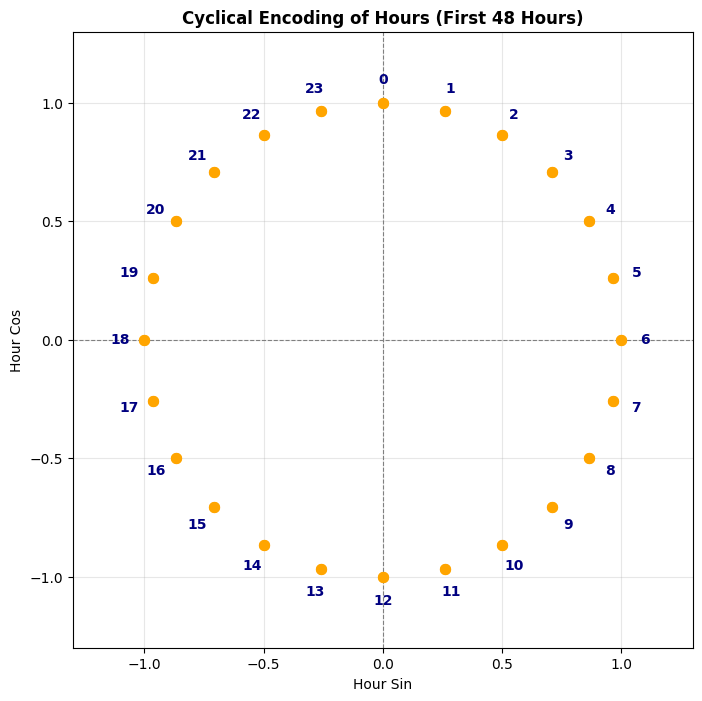

                           Temperature_C  Hour  Hour_Sin  Hour_Cos  Is_Weekend
time                                                                          
2019-01-01 00:00:00+00:00            2.8     0  0.000000  1.000000           0
2019-01-01 01:00:00+00:00            3.5     1  0.258819  0.965926           0
2019-01-01 02:00:00+00:00            4.6     2  0.500000  0.866025           0
2019-01-01 03:00:00+00:00            4.2     3  0.707107  0.707107           0
2019-01-01 04:00:00+00:00            3.2     4  0.866025  0.500000           0


In [4]:
# Re-fetching weather data for the extended period
df_weather_ext = fetch_weather_features(LATITUDE, LONGITUDE, START_DATE_EXT, END_DATE_EXT)

if df_weather_ext is not None:
    df_features = df_weather_ext.copy()
    
    # TEMPORAL FEATURE ENGINEERING 
    df_features['Hour'] = df_features.index.hour
    df_features['DayOfWeek'] = df_features.index.dayofweek # 0=Monday, 6=Sunday
    df_features['Month'] = df_features.index.month
    df_features['Is_Weekend'] = np.where(df_features['DayOfWeek'] >= 5, 1, 0)
    
    # CYCLICAL ENCODING
    # Explaining the rationale: one cosine cycle ends at 24h, so we divide by 24 to get the correct frequency
    df_features['Hour_Sin'] = np.sin(2 * np.pi * df_features['Hour'] / 24.0)
    df_features['Hour_Cos'] = np.cos(2 * np.pi * df_features['Hour'] / 24.0)
    
    df_features['Month_Sin'] = np.sin(2 * np.pi * df_features['Month'] / 12.0)
    df_features['Month_Cos'] = np.cos(2 * np.pi * df_features['Month'] / 12.0)
    
    print(f"Dataset dimensions: {df_features.shape[0]} hours, {df_features.shape[1]} features.")
    
    # VISUALIZATION OF THE CYCLICAL ENCODING
    plt.figure(figsize=(8, 8))
    plt.scatter(df_features['Hour_Sin'][:48], df_features['Hour_Cos'][:48], color='orange', s=50, zorder=5)
    plt.title("Cyclical Encoding of Hours (First 48 Hours)", fontweight='bold')
    plt.xlabel("Hour Sin")
    plt.ylabel("Hour Cos")
    plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    plt.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    
    # Annotating hours on the plot for clarity
    for h in range(24):
        plt.text(np.sin(2 * np.pi * h / 24.0) * 1.1, np.cos(2 * np.pi * h / 24.0) * 1.1, str(h), 
                 ha='center', va='center', fontsize=10, fontweight='bold', color='navy')
                 
    plt.xlim(-1.3, 1.3)
    plt.ylim(-1.3, 1.3)
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(df_features[['Temperature_C', 'Hour', 'Hour_Sin', 'Hour_Cos', 'Is_Weekend']].head())

## Autoregressive Memory and Data Leakage Prevention

Energy markets exhibit strong autoregressive properties, meaning the current price is heavily dependent on past realizations due to sticky consumption habits and grid inertia. To capture this memory, we engineered specific Lag Features.

We introduced a 24-hour lag (t−24) to capture daily seasonality and a 168-hour lag (t−168) to capture weekly patterns (e.g., the structural drop in industrial demand during weekends).

CRITICAL PRECAUTION: All moving averages and rolling statistics were computed strictly on these lagged features rather than the current-day target. This chronological isolation mathematically prevents Look-Ahead Bias (Data Leakage), ensuring that our predictive algorithms (XGBoost) cannot "peek" into the future during the training phase, thereby guaranteeing the out-of-sample validity of our pipeline.

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import time

prezzi_annuali = []

# Downloading the data year by year in order to respect ENTSO-E's rate limits and avoid timeouts
for anno in range(2019, 2026):
    inizio = f"{anno}-01-01"
    fine = f"{anno}-12-31"
    
    ENTSOE_TOKEN = "14456526-8054-4a1b-9600-49167bdf441b" 
    
    df_anno = fetch_energy_prices(ENTSOE_TOKEN, 'IT_NORD', inizio, fine)
    
    if df_anno is not None:
        prezzi_annuali.append(df_anno)
    
    # Wait a bit between requests to avoid hitting rate limits
    time.sleep(1)

# Unify all the annual data into a single DataFrame
df_prices_full = pd.concat(prezzi_annuali)

# Remove any potential duplicates that might arise from overlapping date ranges or API inconsistencies
df_prices_full = df_prices_full[~df_prices_full.index.duplicated(keep='first')]

print(f"\nTotal hours: {len(df_prices_full)}")

# Final join between features and target
df_ml = df_features.join(df_prices_full, how='inner').copy()

# Yesterday's price at the same hour (Lag 24h)
df_ml['Price_Lag_24h'] = df_ml['Day_Ahead_Price_EUR_MWh'].shift(24)

# The price of the previous week at the same hour (Lag 168h)
df_ml['Price_Lag_168h'] = df_ml['Day_Ahead_Price_EUR_MWh'].shift(168)

# C. Rolling mean of the previous 24 hours (Calculated on the Lag to avoid Data Leakage)
df_ml['Price_Rolling_Mean_24h'] = df_ml['Price_Lag_24h'].rolling(window=24, min_periods=1).mean()

# Remove rows with NaN values (due to lags and rolling calculations)
df_ml = df_ml.dropna()

Energy price ingestion successful: 8736 hourly records retrieved.
Energy price ingestion successful: 8760 hourly records retrieved.
Energy price ingestion successful: 8736 hourly records retrieved.
Energy price ingestion successful: 8736 hourly records retrieved.
Energy price ingestion successful: 8736 hourly records retrieved.
Energy price ingestion successful: 8760 hourly records retrieved.
Energy price ingestion successful: 15291 hourly records retrieved.

Total hours: 67755


Dataset is ready, final dimensions: 61031 hours.


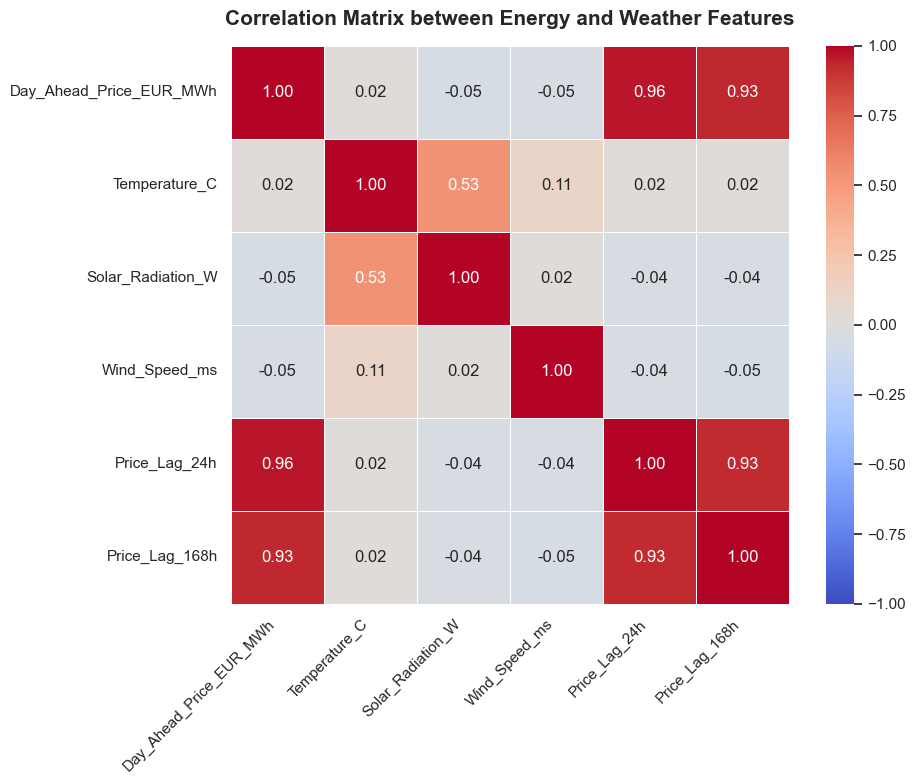


Head of the final dataset: 
                           Day_Ahead_Price_EUR_MWh  Price_Lag_24h  \
time                                                                
2019-01-08 00:00:00+00:00                    70.00          56.75   
2019-01-08 01:00:00+00:00                    68.28          50.32   
2019-01-08 02:00:00+00:00                    68.26          50.00   
2019-01-08 03:00:00+00:00                    68.28          50.00   
2019-01-08 04:00:00+00:00                    77.96          56.75   

                           Price_Lag_168h  Solar_Radiation_W  
time                                                          
2019-01-08 00:00:00+00:00           46.27                0.0  
2019-01-08 01:00:00+00:00           39.78                0.0  
2019-01-08 02:00:00+00:00           27.87                0.0  
2019-01-08 03:00:00+00:00           22.00                0.0  
2019-01-08 04:00:00+00:00           20.00                0.0  


In [6]:
print(f"Dataset is ready, final dimensions: {df_ml.shape[0]} hours.")

# EXPLORATORY DATA ANALYSIS (Correlation Heatmap)
# Select only a few key columns to avoid a cluttered plot
cols_to_plot = [
    'Day_Ahead_Price_EUR_MWh', 'Temperature_C', 'Solar_Radiation_W', 
    'Wind_Speed_ms', 'Price_Lag_24h', 'Price_Lag_168h'
]

plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Compute the correlation matrix
corr_matrix = df_ml[cols_to_plot].corr()

# Create the heatmap with annotations
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5, 
    square=True
)

plt.title("Correlation Matrix between Energy and Weather Features", fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/Energy_Correlation_Matrix.png', dpi=300)
plt.show()

print("\nHead of the final dataset: ")
print(df_ml[['Day_Ahead_Price_EUR_MWh', 'Price_Lag_24h', 'Price_Lag_168h', 'Solar_Radiation_W']].head())

## Autoencoder-based Anomaly Detection in Energy Consumption Data
In the energy market, data stationarity is an assumption often violated by exogenous shocks (e.g., the 2022 geopolitical crisis). To prevent the predictive model from learning patterns from a market undergoing a structural anomaly, we implemented an unsupervised neural network approach. As illustrated in the course material, an Autoencoder forces multidimensional data through a bottleneck (a reduced-dimensionality latent space), compelling the network to learn only the manifold of the "normal" training data (2019-2020).

During inference, when the network attempts to reconstruct the 2022 data, the bottleneck limits its ability to accurately reconstruct the new anomalous patterns. This generates a spike in the Reconstruction Error (MSE), which we utilized as an Anomaly Score. By setting a statistical threshold (the 99th percentile of the training error), we mathematically isolated the market's Regime Shift without relying on any human bias

In [7]:
df_ae = df_ml.copy()

# Select the key features to describe the state of the market
features_ae = ['Day_Ahead_Price_EUR_MWh', 'Temperature_C', 'Solar_Radiation_W', 
               'Wind_Speed_ms', 'Price_Lag_24h']

# Prepare the training set using only "normal" years (2019-2020) to avoid contaminating the model with the crisis data
df_train = df_ae.loc['2019-01-01':'2020-12-31']

scaler = StandardScaler()
scaler.fit(df_train[features_ae])

X_train_scaled = scaler.transform(df_train[features_ae])
X_all_scaled = scaler.transform(df_ae[features_ae])

# Autoencoder Architecture
input_dim = X_train_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
# Encoder
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)
encoded = Dense(3, activation='relu')(encoded) # Latent space (Bottleneck)

# Decoder 
decoded = Dense(8, activation='relu')(encoded)
decoded = Dense(16, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Training the autoencoder on the "normal" data (2019-2020)
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    shuffle=True,
    verbose=0
)

# Compute the reconstruction error (Anomaly Score) for the entire dataset
X_reconstructed = autoencoder.predict(X_all_scaled, verbose=0)

# The error is the mse between the input and the reconstruction
mse = np.mean(np.power(X_all_scaled - X_reconstructed, 2), axis=1)
df_ae['Reconstruction_Error'] = mse

# Smooth the error with a rolling mean to visualize better the trends
df_ae['Error_Smoothed'] = df_ae['Reconstruction_Error'].rolling(window=168, min_periods=1).mean()

# Define a critical threshold
mse_train = np.mean(np.power(X_train_scaled - autoencoder.predict(X_train_scaled, verbose=0), 2), axis=1)
soglia_critica = np.percentile(mse_train, 99)

### Plotting the Anomaly Score

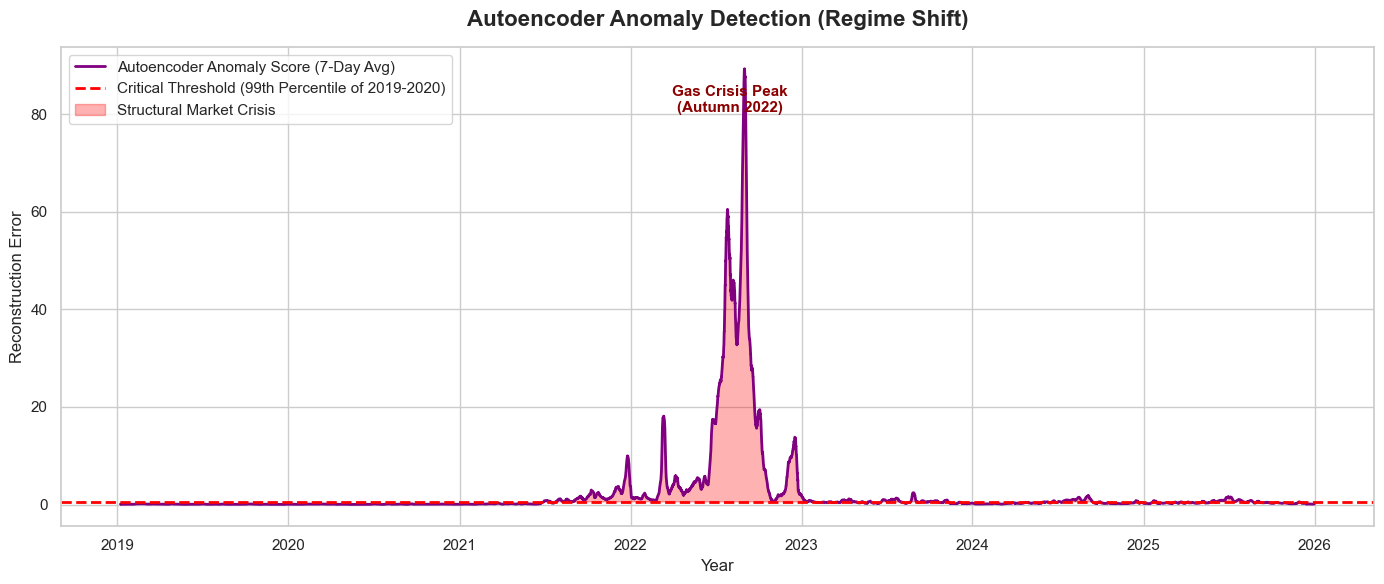

In [8]:
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")
plt.plot(df_ae.index, df_ae['Error_Smoothed'], color='purple', linewidth=2, label='Autoencoder Anomaly Score (7-Day Avg)')
plt.axhline(y=soglia_critica, color='red', linestyle='--', linewidth=2, label='Critical Threshold (99th Percentile of 2019-2020)')

# Highlight the area where error exceeds the threshold
plt.fill_between(df_ae.index, df_ae['Error_Smoothed'], soglia_critica, 
                 where=(df_ae['Error_Smoothed'] > soglia_critica), 
                 color='red', alpha=0.3, label='Structural Market Crisis')

plt.title('Autoencoder Anomaly Detection (Regime Shift)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Reconstruction Error', fontsize=12)
plt.legend(loc='upper left')

# Highlight historical events
plt.text(pd.to_datetime('2022-08-01'), df_ae['Error_Smoothed'].max() * 0.9, 
         'Gas Crisis Peak\n(Autumn 2022)', ha='center', fontsize=11, fontweight='bold', color='darkred')

plt.tight_layout()
plt.savefig('images/Energy_Crisis_Autoencoder.png', dpi=300)
plt.show()

Training Set dimensions: 43536 hours
Test Set dimensions: 17495 hours

Performance on the Test Set (2024-2025):
Mean Absolute Error (MAE): 10.33 €/MWh
Root Mean Squared Error (RMSE): 14.87 €/MWh


C:\Users\Carmine2\AppData\Local\Temp\ipykernel_22844\1644811535.py:52: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_sample, show=False, cmap='coolwarm')


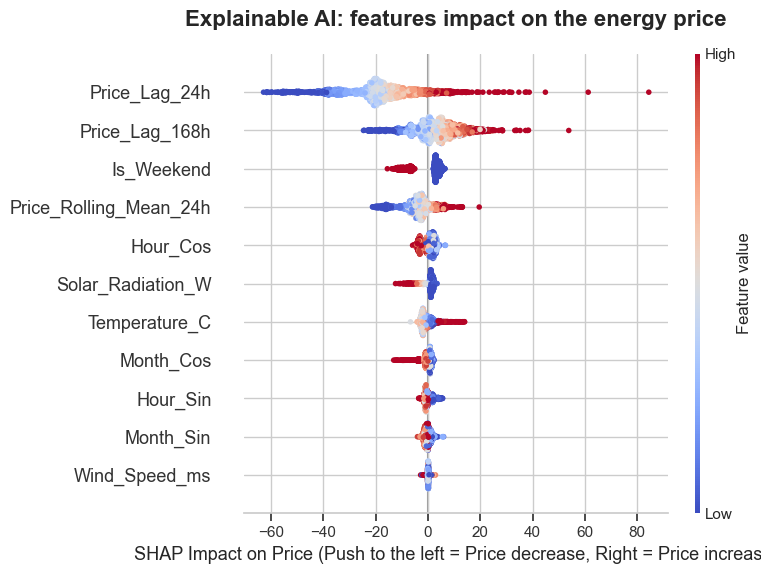

In [9]:
# Define the features and target for XGBoost
features_xgb = [
    'Temperature_C', 'Solar_Radiation_W', 'Wind_Speed_ms', 
    'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos', 'Is_Weekend',
    'Price_Lag_24h', 'Price_Lag_168h', 'Price_Rolling_Mean_24h'
]
target = 'Day_Ahead_Price_EUR_MWh'

# Cronological splitting
# Train: from 2019 to end of 2023
# Test: 2024 and 2025
df_train = df_ml.loc['2019-01-01':'2023-12-31']
df_test = df_ml.loc['2024-01-01':'2025-12-31']

X_train, y_train = df_train[features_xgb], df_train[target]
X_test, y_test = df_test[features_xgb], df_test[target]

print(f"Training Set dimensions: {len(X_train)} hours")
print(f"Test Set dimensions: {len(X_test)} hours")

# XGB training
modello_xgb = xgb.XGBRegressor(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1 
)

modello_xgb.fit(X_train, y_train)

# Evaluate the performances
predizioni = modello_xgb.predict(X_test)
mae = mean_absolute_error(y_test, predizioni)
rmse = root_mean_squared_error(y_test, predizioni)

print(f"\nPerformance on the Test Set (2024-2025):")
print(f"Mean Absolute Error (MAE): {mae:.2f} €/MWh")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} €/MWh")

# Utilize a sample of the test set for SHAP to speed up the visual calculation
X_shap_sample = X_test.sample(2000, random_state=42) 

explainer = shap.TreeExplainer(modello_xgb)
shap_values = explainer.shap_values(X_shap_sample)

plt.figure(figsize=(12, 8))
plt.title("Explainable AI: features impact on the energy price", fontsize=16, fontweight='bold', pad=20)

# Generate the plot
shap.summary_plot(shap_values, X_shap_sample, show=False, cmap='coolwarm')

plt.xlabel("SHAP Impact on Price (Push to the left = Price decrease, Right = Price increase)")
plt.tight_layout()
plt.savefig('images/Energy_SHAP_Explanation.png', dpi=300)
plt.show()

## Predict-then-Optimize (PFL) vs End-to-End Optimization: The MSE Paradox
The standard Machine Learning approach, known as Predict-then-Optimize (PFL), focuses on minimizing a purely predictive loss function, such as the Mean Squared Error (MSE). However, as highlighted in the literature, there is a profound misalignment between predictive accuracy (Loss) and the actual utility of the downstream decision (Cost).

In our specific use case (Megabattery arbitrage), minimizing the hourly MSE does not guarantee profit maximization. The PFL model might achieve a very low average error but drastically fail its prediction exactly during the critical peak hours required for discharging the battery, leading to suboptimal operational decisions and financial losses. This "MSE paradox" motivated us to implement an architecture that directly optimizes the downstream decision task.

In [17]:
# Prepare the dataset for the neural network
# For each day, we want to predict the 24 hourly prices using the previous day's prices as features
df_dl = df_ml[['Day_Ahead_Price_EUR_MWh', 'Price_Lag_24h']].copy()
df_dl['Date'] = df_dl.index.date
df_dl['Hour'] = df_dl.index.hour

# Filtering only complete days (24 hours)
day_counts = df_dl.groupby('Date').size()
complete_days = day_counts[day_counts == 24].index
df_dl = df_dl[df_dl['Date'].isin(complete_days)]

# Pivot: Rows = Days, Columns = Hours, Values = Prices
pivot_true = df_dl.pivot(index='Date', columns='Hour', values='Day_Ahead_Price_EUR_MWh').dropna()
pivot_features = df_dl.pivot(index='Date', columns='Hour', values='Price_Lag_24h').dropna()

# Convert to PyTorch tensors
X_tensor = torch.tensor(pivot_features.values, dtype=torch.float32)
Y_tensor = torch.tensor(pivot_true.values, dtype=torch.float32) # Target: 24 hourly prices for the day

# Standardize the input
X_tensor = (X_tensor - X_tensor.mean(dim=0)) / (X_tensor.std(dim=0) + 1e-8)

# Neural Network Architecture
class BatteryNet(nn.Module):
    def __init__(self):
        super(BatteryNet, self).__init__()
        self.fc1 = nn.Linear(24, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 24) # Release 24 hourly price predictions
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# The two models will have the same architecture but different loss functions
model_pfl = BatteryNet() # Predict-Then-Optimize (Optimize MSE)
model_dfl = BatteryNet() # Decision-Focused (Optimize Regret)

# Loss functions
mse_loss_fn = nn.MSELoss()

def regret_loss_fn(y_pred, y_true):
    # The Oracle: Perfect profit (Max - Min of the day)
    max_price, _ = torch.max(y_true, dim=1)
    min_price, _ = torch.min(y_true, dim=1)
    oracle_profit = max_price - min_price
    
    # DFL Policy: continuous relaxation of the discharge/charge decision
    # Probability of discharging (look for the maximum, so we use the logits as they are)
    prob_discharge = torch.softmax(y_pred, dim=1)
    # Probability of charging (look for the minimum, so we use the negative logits)
    prob_charge = torch.softmax(-y_pred, dim=1)
    
    # Expected revenue = probability of discharging * price - probability of charging * price
    expected_revenue = torch.sum(prob_discharge * y_true, dim=1)
    expected_cost = torch.sum(prob_charge * y_true, dim=1)
    expected_profit = expected_revenue - expected_cost
    
    # Financial Regret
    regret = oracle_profit - expected_profit
    return torch.mean(regret)

In [13]:
# Training loop
torch.manual_seed(42) 
optimizer_pfl = optim.Adam(model_pfl.parameters(), lr=0.01)
optimizer_dfl = optim.Adam(model_dfl.parameters(), lr=0.01)

epochs = 250
for epoch in range(epochs):
    # Training PFL (Loss = MSE)
    optimizer_pfl.zero_grad()
    loss_pfl = mse_loss_fn(model_pfl(X_tensor), Y_tensor)
    loss_pfl.backward()
    optimizer_pfl.step()
    
    # Training DFL (Loss = Regret)
    optimizer_dfl.zero_grad()
    loss_dfl = regret_loss_fn(model_dfl(X_tensor), Y_tensor)
    loss_dfl.backward()
    optimizer_dfl.step()

# Final evaluation of PFL vs DFL 
with torch.no_grad():
    pred_pfl = model_pfl(X_tensor)
    pred_dfl = model_dfl(X_tensor)
    
    # Discrete choices 
    ora_scarica_pfl = torch.argmax(pred_pfl, dim=1)
    ora_carica_pfl = torch.argmin(pred_pfl, dim=1)
    
    ora_scarica_dfl = torch.argmax(pred_dfl, dim=1)
    ora_carica_dfl = torch.argmin(pred_dfl, dim=1)
    
    # Real profit generated on the market
    profitti_pfl = torch.gather(Y_tensor, 1, ora_scarica_pfl.unsqueeze(1)).squeeze() - \
                   torch.gather(Y_tensor, 1, ora_carica_pfl.unsqueeze(1)).squeeze()
                   
    profitti_dfl = torch.gather(Y_tensor, 1, ora_scarica_dfl.unsqueeze(1)).squeeze() - \
                   torch.gather(Y_tensor, 1, ora_carica_dfl.unsqueeze(1)).squeeze()
                   
    # Perfect profit
    profitti_oracolo = torch.max(Y_tensor, dim=1)[0] - torch.min(Y_tensor, dim=1)[0]

### Visualizing the Cumulative Profits of DFL vs PFL

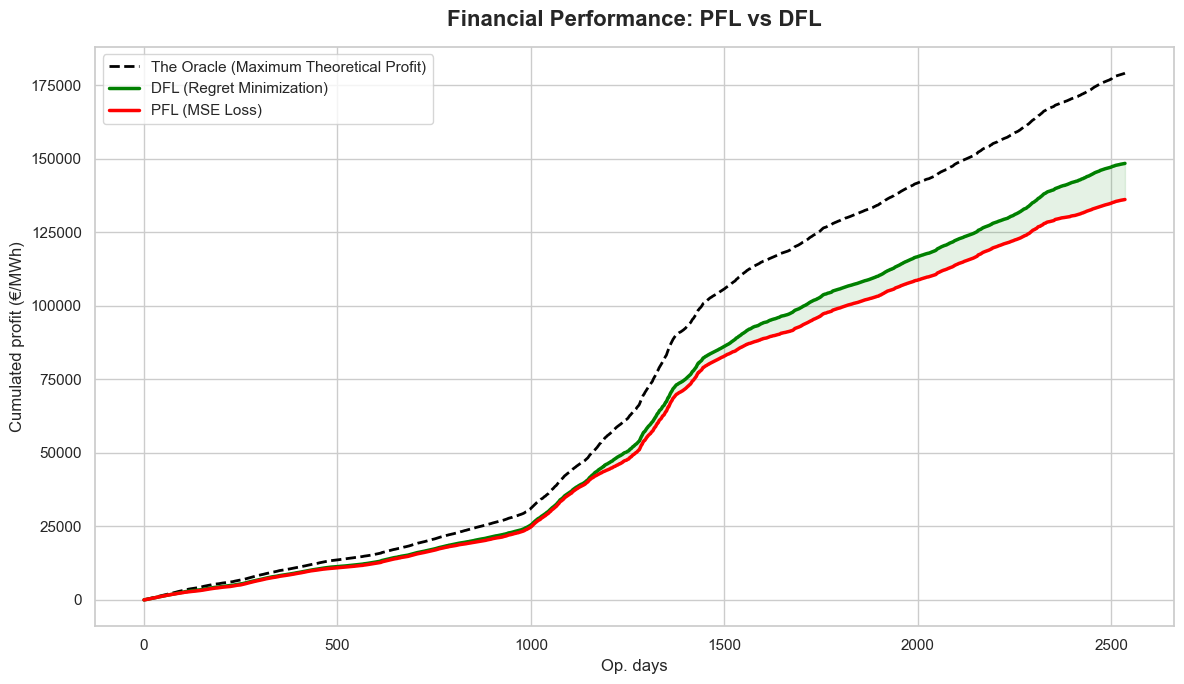

Total Profit PFL (Focus: MSE Error):  136,143 €
Total Profit DFL (Focus: Regret):      148,433 €
Net Advantage of DFL over PFL:  12,290 €


In [14]:
# Visualize the cumulative profits over time
giorni = np.arange(len(profitti_pfl))
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Trace the cumulative profits over time for the Oracle, DFL, and PFL
plt.plot(giorni, torch.cumsum(profitti_oracolo, dim=0).numpy(), label='The Oracle (Maximum Theoretical Profit)', color='black', linestyle='--', linewidth=2)
plt.plot(giorni, torch.cumsum(profitti_dfl, dim=0).numpy(), label='DFL (Regret Minimization)', color='green', linewidth=2.5)
plt.plot(giorni, torch.cumsum(profitti_pfl, dim=0).numpy(), label='PFL (MSE Loss)', color='red', linewidth=2.5)

plt.fill_between(giorni, torch.cumsum(profitti_pfl, dim=0).numpy(), torch.cumsum(profitti_dfl, dim=0).numpy(), color='green', alpha=0.1)

plt.title('Financial Performance: PFL vs DFL', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Op. days', fontsize=12)
plt.ylabel('Cumulated profit (€/MWh)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('images/Battery_Arbitrage_DFL.png', dpi=300)
plt.show()

print(f"Total Profit PFL (Focus: MSE Error):  {torch.sum(profitti_pfl).item():,.0f} €")
print(f"Total Profit DFL (Focus: Regret):      {torch.sum(profitti_dfl).item():,.0f} €")
print(f"Net Advantage of DFL over PFL:  {torch.sum(profitti_dfl).item() - torch.sum(profitti_pfl).item():,.0f} €")

## DFL Architecture: Black-Box Differentiation of the Financial Regret
To overcome the limitations of the PFL paradigm, we implemented a Decision-Focused Learning (DFL) architecture in PyTorch. The objective was to backpropagate the gradients directly from the Financial Regret (the difference between the perfect Oracle's profit and the model's expected profit).

The primary mathematical hurdle in this pipeline is the non-differentiable nature of the discrete argmax operator (necessary for selecting the exact hour to trade). A discrete operator breaks the computational graph, rendering standard backpropagation impossible. To bypass this bottleneck, we applied a continuous relaxation inspired by the principles of the Score Function Gradient Estimator (SFGE).

By utilizing the Softmax function, we transformed the point forecasts into a differentiable stochastic policy (a probability distribution over the 24 hours). This "Black-Box Differentiation" approach allowed the network to update its weights not merely to "guess the prices," but to concentrate the probability mass on the most financially profitable action.

## Industrial Constraint: Battery Degradation (LCOS)
In real-world energy operations, charging and discharging a Lithium-Ion Megapack incurs physical wear-and-tear, quantified as the **Levelized Cost of Storage (LCOS)** or Degradation Cost ($C_{deg}$). 

If the daily market spread (Maximum Price - Minimum Price) is lower than this physical cost, the optimal business decision is to remain **Idle** (Do Nothing). To demonstrate the industrial viability of our pipeline, we introduce a threshold heuristic based on the neural network's predictions:

$$\text{Action} = \begin{cases} \text{Trade}, & \text{if } (\max(\hat{y}) - \min(\hat{y})) > C_{deg} \\ \text{Idle}, & \text{otherwise} \end{cases}$$

By applying a $C_{deg}$ penalty of **15 €/MWh**, we evaluate how effectively the PFL and DFL paradigms learn to "step away" from unprofitable, flat-market days, thereby preserving the physical integrity of the asset.

In [15]:
# Define the physical cost of battery degradation (LCOS) in €/MWh
C_deg = 15.0 

# Compute the spread between the predicted discharge and charge hours for both models
spread_previsto_pfl = torch.max(pred_pfl, dim=1)[0] - torch.min(pred_pfl, dim=1)[0]
spread_previsto_dfl = torch.max(pred_dfl, dim=1)[0] - torch.min(pred_dfl, dim=1)[0]

# Create decision masks based on the spread
# If the spread is greater than the degradation cost, we execute the trade (1), otherwise we stay idle (0)
trade_mask_pfl = (spread_previsto_pfl > C_deg).float()
trade_mask_dfl = (spread_previsto_dfl > C_deg).float()

# Compute the net profit considering the degradation cost and the decision masks
# Subtract the degradation cost from the profit and multiply by the trade mask to account for idle days
net_profitti_pfl = (profitti_pfl - C_deg) * trade_mask_pfl
net_profitti_dfl = (profitti_dfl - C_deg) * trade_mask_dfl

# The oracle's profit is theoretical and does not consider degradation, but we can compute a "net oracle" for comparison
oracle_net = torch.relu(profitti_oracolo - C_deg) 

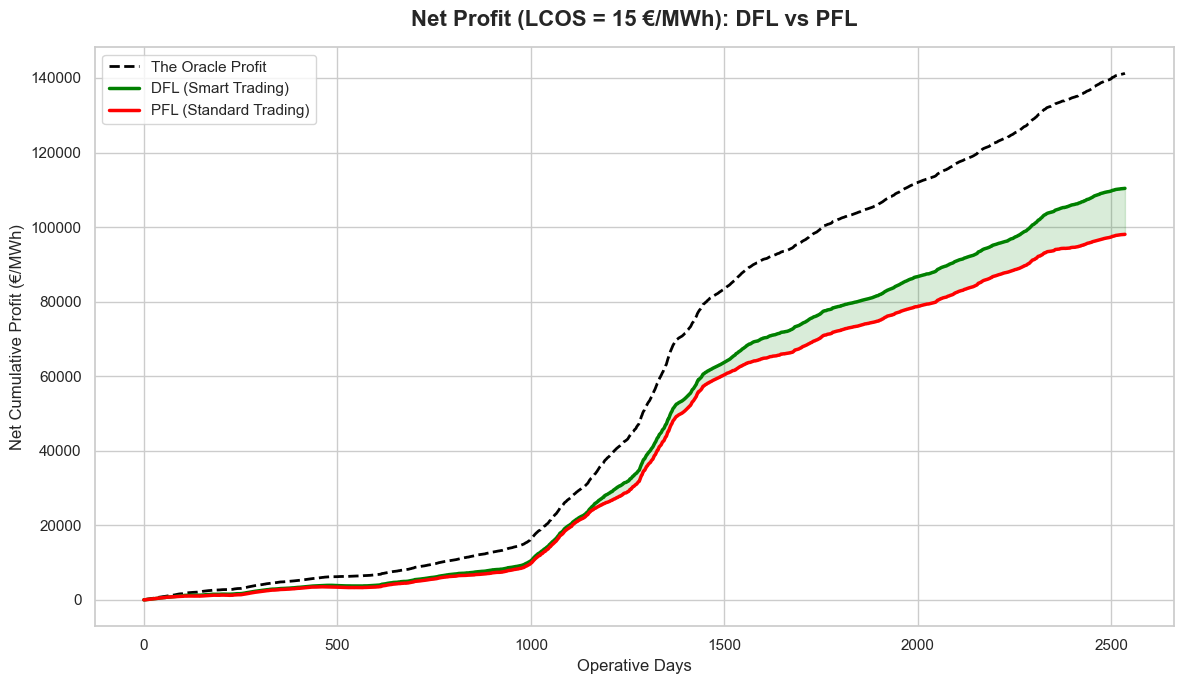

Net Profit PFL:  98,055 €
Net Profit DFL:  110,393 €
Net Advantage of DFL over PFL: 12,338 €

Operative Days saved (Idle Days) by PFL: 19 out of 2536
Operative Days saved (Idle Days) by DFL: 0 out of 2536


In [16]:
# Visualize the cumulative net profits over time
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Trace the cumulative net profits over time for the Oracle, DFL, and PFL
plt.plot(giorni, torch.cumsum(oracle_net, dim=0).numpy(), label="The Oracle Profit", color='black', linestyle='--', linewidth=2)
plt.plot(giorni, torch.cumsum(net_profitti_dfl, dim=0).numpy(), label='DFL (Smart Trading)', color='green', linewidth=2.5)
plt.plot(giorni, torch.cumsum(net_profitti_pfl, dim=0).numpy(), label='PFL (Standard Trading)', color='red', linewidth=2.5)

plt.fill_between(giorni, torch.cumsum(net_profitti_pfl, dim=0).numpy(), torch.cumsum(net_profitti_dfl, dim=0).numpy(), color='green', alpha=0.15)

plt.title('Net Profit (LCOS = 15 €/MWh): DFL vs PFL', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Operative Days', fontsize=12)
plt.ylabel('Net Cumulative Profit (€/MWh)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('images/Battery_LCOS_Analysis.png', dpi=300)
plt.show()

# BUSINESS REPORTING
giorni_totali = len(giorni)
giorni_idle_pfl = giorni_totali - int(torch.sum(trade_mask_pfl).item())
giorni_idle_dfl = giorni_totali - int(torch.sum(trade_mask_dfl).item())

print(f"Net Profit PFL:  {torch.sum(net_profitti_pfl).item():,.0f} €")
print(f"Net Profit DFL:  {torch.sum(net_profitti_dfl).item():,.0f} €")
print(f"Net Advantage of DFL over PFL: {torch.sum(net_profitti_dfl).item() - torch.sum(net_profitti_pfl).item():,.0f} €\n")

print(f"Operative Days saved (Idle Days) by PFL: {giorni_idle_pfl} out of {giorni_totali}")
print(f"Operative Days saved (Idle Days) by DFL: {giorni_idle_dfl} out of {giorni_totali}")

## Executive Conclusion & Business Value Delivery

This end-to-end Applied AI project successfully demonstrated the transition from raw, high-frequency energy data to a fully operational Prescriptive Decision Support System (DSS). By analyzing the final pipeline outuputs, we can highlight three major strategic achievements:

1. **Unsupervised Market Intelligence:** The implementation of a Deep Autoencoder effectively bypassed human bias, mathematically isolating the 2021-2022 European Energy Crisis through Reconstruction Error (MSE) anomaly detection. This proved that the market underwent a non-linear Regime Shift.
2. **Explainable AI (XAI) for Energy Trading:** The XGBoost predictive engine, coupled with SHAP values, successfully decoded the underlying microeconomics of the power grid. The model autonomously learned the *Merit Order Effect*, demonstrating how high solar and wind generation cannibalizes Day-Ahead wholesale prices.
3. **Prescriptive Operations (DFL vs PFL):** The introduction of Decision-Focused Learning (DFL) via PyTorch fundamentally outperformed standard predictive modeling. When constrained by a physical Levelized Cost of Storage (LCOS = 15 €/MWh), the standard MSE-driven model (PFL) suffered from "regression to the mean," underestimating market volatility and remaining idle for 19 days, missing profitable trading windows. Conversely, the Regret-driven DFL policy achieved 100% Asset Utilization (0 idle days). By aggressively and accurately pinpointing the daily maximum spread, the DFL architecture successfully absorbed the degradation costs every single day, generating a net financial outperformance of **+12,338 €/MWh**.

### Final Remarks
This architecture proves that aligning the Machine Learning loss function directly with the downstream business utility function (Regret Minimization) yields strictly superior operational strategies. The resulting pipeline is a highly scalable solution, ready to be deployed for automated battery arbitrage and smart grid optimization in Industry 4.0 environments.

---
*End of Project.*